## Loading necessary libraries

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Labels --> using this for personal reference
- 1 = Healthy Controls
- 2 = Patients

## Importing the dataset using pandas

In [41]:
df = pd.read_csv('breastcancer.csv')
df.head()

,Age,BMI,Glucose,Insulin,HOMA,Leptin,Adiponectin,Resistin,MCP.1,Classification
0,48,23.500000,70,2.707,0.467409,8.8071,9.702400,7.99585,417.114,1
1,83,20.690495,92,3.115,0.706897,8.8438,5.429285,4.06405,468.786,1
2,82,23.124670,91,4.498,1.009651,17.9393,22.432040,9.27715,554.697,1
3,68,21.367521,77,3.226,0.612725,9.8827,7.169560,12.76600,928.220,1
4,86,21.111111,92,3.549,0.805386,6.6994,4.819240,10.57635,773.920,1


## Basic EDA (Exploratory Data Analysis) on Data Frame

In [42]:
df.columns # this will give us the column names

Index(['Age', 'BMI', 'Glucose', 'Insulin', 'HOMA', 'Leptin', 'Adiponectin',
       'Resistin', 'MCP.1', 'Classification'],
      dtype='object')

In [43]:
df.columns.tolist() # this will give us the column names without the Index and dtype

['Age',
 'BMI',
 'Glucose',
 'Insulin',
 'HOMA',
 'Leptin',
 'Adiponectin',
 'Resistin',
 'MCP.1',
 'Classification']

In [44]:
df.info() # using info() to get an idea of non-null count, data type

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116 entries, 0 to 115
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             116 non-null    int64  
 1   BMI             116 non-null    float64
 2   Glucose         116 non-null    int64  
 3   Insulin         116 non-null    float64
 4   HOMA            116 non-null    float64
 5   Leptin          116 non-null    float64
 6   Adiponectin     116 non-null    float64
 7   Resistin        116 non-null    float64
 8   MCP.1           116 non-null    float64
 9   Classification  116 non-null    int64  
dtypes: float64(7), int64(3)
memory usage: 9.2 KB


In [45]:
df.isnull().sum() # double checking if there are any null values in dataset 

Age               0
BMI               0
Glucose           0
Insulin           0
HOMA              0
Leptin            0
Adiponectin       0
Resistin          0
MCP.1             0
Classification    0
dtype: int64

In [46]:
df.describe().transpose() # Basic decriptive stats on dataset

,count,mean,std,min,25%,50%,75%,max
Age,116.0,57.301724,16.112766,24.000000,45.000000,56.000000,71.000000,89.000000
BMI,116.0,27.582111,5.020136,18.370000,22.973205,27.662416,31.241442,38.578759
Glucose,116.0,97.793103,22.525162,60.000000,85.750000,92.000000,102.000000,201.000000
Insulin,116.0,10.012086,10.067768,2.432000,4.359250,5.924500,11.189250,58.460000
HOMA,116.0,2.694988,3.642043,0.467409,0.917966,1.380939,2.857787,25.050342
Leptin,116.0,26.615080,19.183294,4.311000,12.313675,20.271000,37.378300,90.280000
Adiponectin,116.0,10.180874,6.843341,1.656020,5.474283,8.352692,11.815970,38.040000
Resistin,116.0,14.725966,12.390646,3.210000,6.881763,10.827740,17.755207,82.100000
MCP.1,116.0,534.647000,345.912663,45.843000,269.978250,471.322500,700.085000,1698.440000
Classification,116.0,1.551724,0.499475,1.000000,1.000000,2.000000,2.000000,2.000000


In [47]:
df.corr().round(2) # this gives us correlation table. Kind of hard on the eyes

,Age,BMI,Glucose,Insulin,HOMA,Leptin,Adiponectin,Resistin,MCP.1,Classification
Age,1.00,0.01,0.23,0.03,0.13,0.10,-0.22,0.00,0.01,-0.04
BMI,0.01,1.00,0.14,0.15,0.11,0.57,-0.30,0.20,0.22,-0.13
Glucose,0.23,0.14,1.00,0.50,0.70,0.31,-0.12,0.29,0.26,0.38
Insulin,0.03,0.15,0.50,1.00,0.93,0.30,-0.03,0.15,0.17,0.28
HOMA,0.13,0.11,0.70,0.93,1.00,0.33,-0.06,0.23,0.26,0.28
Leptin,0.10,0.57,0.31,0.30,0.33,1.00,-0.10,0.26,0.01,-0.00
Adiponectin,-0.22,-0.30,-0.12,-0.03,-0.06,-0.10,1.00,-0.25,-0.20,-0.02
Resistin,0.00,0.20,0.29,0.15,0.23,0.26,-0.25,1.00,0.37,0.23
MCP.1,0.01,0.22,0.26,0.17,0.26,0.01,-0.20,0.37,1.00,0.09
Classification,-0.04,-0.13,0.38,0.28,0.28,-0.00,-0.02,0.23,0.09,1.00


<Axes: >

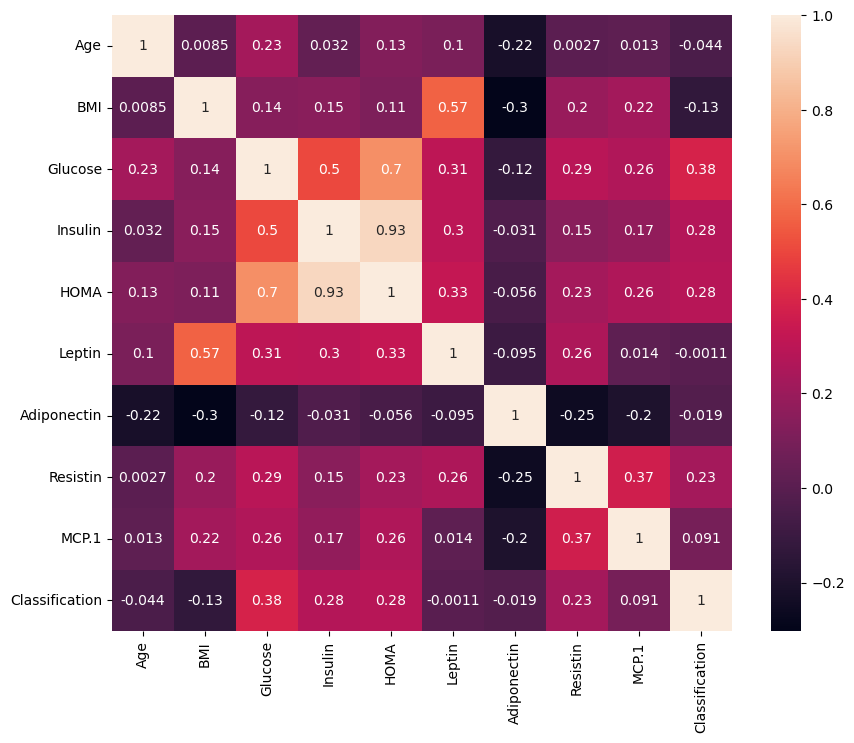

In [48]:
# created a heat map to give us an idea of correlation levels and something visually easier on the eyes


plt.figure(figsize=(10,8))
corr = sns.heatmap(data = df.corr(numeric_only = True), annot = True)

corr

# Building a Logistic Regression Model

In [49]:
from sklearn.model_selection import train_test_split
from sklearn import metrics

In [50]:
# we will separate features and target variable

X = df.drop('Classification', axis=1)
y = df['Classification']

In [51]:
X.head()

,Age,BMI,Glucose,Insulin,HOMA,Leptin,Adiponectin,Resistin,MCP.1
0,48,23.500000,70,2.707,0.467409,8.8071,9.702400,7.99585,417.114
1,83,20.690495,92,3.115,0.706897,8.8438,5.429285,4.06405,468.786
2,82,23.124670,91,4.498,1.009651,17.9393,22.432040,9.27715,554.697
3,68,21.367521,77,3.226,0.612725,9.8827,7.169560,12.76600,928.220
4,86,21.111111,92,3.549,0.805386,6.6994,4.819240,10.57635,773.920


In [52]:
y.head()

0    1
1    1
2    1
3    1
4    1
Name: Classification, dtype: int64

## Splitting the data into Train and Test sets

In [53]:
from sklearn import linear_model

In [54]:
# we are spliting the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size= .3, random_state= 42)

In [55]:
lr = linear_model.LogisticRegression()

In [56]:
lr.fit(X_train, y_train)

C:\Users\noahh\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [57]:
lr.coef_

array([[-0.04326171, -0.17782549,  0.07515717,  0.04538951,  0.10809614,
        -0.00320515, -0.05160462,  0.02673811,  0.00058278]])

In [58]:
lr.intercept_

array([-0.13050537])

## Creating a function for the Logistic Regression Model using Train and Test sets
- Displaying confusion maxtrices, accuracy scores, and correct predictions

In [59]:
# I will create a function to make it look cleaner, instead of using individual cells

def evaluate_model(lr, X_train, X_test, y_train, y_test):
    
    # Making predictions
    train_pred = lr.predict(X_train)
    test_pred = lr.predict(X_test)
    
    # Getting accuracy scores
    train_accuracy,test_accuracy = (round(metrics.accuracy_score(y_train, train_pred) * 100, 2), 
                                    round(metrics.accuracy_score(y_test, test_pred) * 100, 2))
    
    print(f"Accuracy score for train set:  {train_accuracy} %")
    print(f"Accuracy score for test set:  {test_accuracy} %")
    
    # Creating confusion matrices
    train_cm, test_cm = (metrics.confusion_matrix(y_train, train_pred), 
                         metrics.confusion_matrix(y_test, test_pred))
    
    print("\nTraining Confusion Matrix:")
    print(train_cm)
    
    print("\nTesting Confusion Matrix:")
    print(test_cm)
    
    # Pulling correct predictions from the diagonal
    train_healthy = train_cm.diagonal()[0]
    train_patients = train_cm.diagonal()[1]
    train_total_correct = train_cm.diagonal().sum()
    
    test_healthy = test_cm.diagonal()[0]
    test_patients = test_cm.diagonal()[1]
    test_total_correct = test_cm.diagonal().sum()
    
    # Show training results
    print("\nTraining Data Results:")
    print(f"Correct amount of predictions for class 1 Healthy Controls: {train_healthy}")
    print(f"Correct amount of predictions for class 2 Patients: {train_patients}")
    print(f"Correct amount of predictions made for both classes using the training data: {train_total_correct}")
    
    # Show testing results
    print("\nTesting Data Results:")
    print(f"Correct amount of predictions for class 1 Healthy Controls: {test_healthy}")
    print(f"Correct amount of predictions for class 2 Patients: {test_patients}")
    print(f"Correct amount of predictions made for both classes using the testing data: {test_total_correct}")
    
    return train_cm, test_cm


# Calling the function so the output shows
train_cm, test_cm = evaluate_model(lr, X_train, X_test, y_train, y_test)

Accuracy score for train set:  76.54 %
Accuracy score for test set:  77.14 %

Training Confusion Matrix:
[[26  9]
 [10 36]]

Testing Confusion Matrix:
[[12  5]
 [ 3 15]]

Training Data Results:
Correct amount of predictions for class 1 Healthy Controls: 26
Correct amount of predictions for class 2 Patients: 36
Correct amount of predictions made for both classes using the training data: 62

Testing Data Results:
Correct amount of predictions for class 1 Healthy Controls: 12
Correct amount of predictions for class 2 Patients: 15
Correct amount of predictions made for both classes using the testing data: 27


## Analysis of Logistic Regression

The Logistics Regression model had a training accuracy of 76.54 % and a test accuracy of 77.14 %. In the training confusion matrix, the model correctly predicted 26 healthy controls and 36 patients. In the test confusion matrix, the model correctly predicted 12 healthy controls and 15 patients. It incorrectly predicted 5 healthy controls as patients and 3 patients as healthy controls is the test set. With a total of 62 (training) and 27 (testing) correct predictions using the training and test sets.

# Building a Naive Bayes Model 

In [21]:
from sklearn.naive_bayes import GaussianNB

NB = GaussianNB()

NB.fit(X_train,y_train)
GaussianNB(priors=None)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


## Creating a function for the Naive Bayes Model using Train and Test sets
- Displaying confusion maxtrices, accuracy scores, and correct predictions

In [22]:
# creating a function for Naive Bayes Model

def model_evaluation_NB(NB,X_train, X_test, y_train, y_test):

    NB_train_pred = NB.predict(X_train)
    NB_test_pred = NB.predict(X_test)

    # Getting accuracy scores
    NB_train_accuracy,NB_test_accuracy = (round(metrics.accuracy_score(y_train, NB_train_pred) * 100, 2), 
                                    round(metrics.accuracy_score(y_test, NB_test_pred) * 100, 2))

    print(f"Accuracy score for train set: {NB_train_accuracy} %")
    print(f"Accuracy score for test set: {NB_test_accuracy} %")

    # creating matrices for Naive Bayes
    NB_train_cm, NB_test_cm = (metrics.confusion_matrix(y_train, NB_train_pred), 
                         metrics.confusion_matrix(y_test, NB_test_pred))

    print("\nTraining Confusion Matrix:")
    print(NB_train_cm)
    
    print("\nTesting Confusion Matrix:")
    print(NB_test_cm)

    # Pulling correct predictions from the diagonal
    NB_train_healthy = NB_train_cm.diagonal()[0]
    NB_train_patients = NB_train_cm.diagonal()[1]
    NB_train_total_correct = NB_train_cm.diagonal().sum()
    
    NB_test_healthy = NB_test_cm.diagonal()[0]
    NB_test_patients = NB_test_cm.diagonal()[1]
    NB_test_total_correct = NB_test_cm.diagonal().sum()

        # Show training results
    print("\nTraining Data Results:")
    print(f"Correct amount of predictions for class 1 Healthy Controls: {NB_train_healthy}")
    print(f"Correct amount of predictions for class 2 Patients: {NB_train_patients}")
    print(f"Correct amount of predictions made for both classes using the training data: {NB_train_total_correct}")
    
    # Show testing results
    print("\nTesting Data Results:")
    print(f"Correct amount of predictions for class 1 Healthy Controls: {NB_test_healthy}")
    print(f"Correct amount of predictions for class 2 Patients: {NB_test_patients}")
    print(f"Correct amount of predictions made for both classes using the testing data: {NB_test_total_correct}")
    
    return NB_train_cm, NB_test_cm


# Calling the function so the output shows
NB_train_cm, NB_test_cm = model_evaluation_NB(NB, X_train, X_test, y_train, y_test)

Accuracy score for train set: 60.49 %
Accuracy score for test set: 65.71 %

Training Confusion Matrix:
[[31  4]
 [28 18]]

Testing Confusion Matrix:
[[15  2]
 [10  8]]

Training Data Results:
Correct amount of predictions for class 1 Healthy Controls: 31
Correct amount of predictions for class 2 Patients: 18
Correct amount of predictions made for both classes using the training data: 49

Testing Data Results:
Correct amount of predictions for class 1 Healthy Controls: 15
Correct amount of predictions for class 2 Patients: 8
Correct amount of predictions made for both classes using the testing data: 23


## Analysis of Naive Bayes Model

The Naive Baies model had a training accuracy of 60.49% and a test accuracy of 65.71%. In the training confusion matrix, the model correctly predicted 31 healthy controls and 18 patients. In the test confusion matrix, the model correctly predicted 15 healthy controls and 8 patients. It incorrectly predicted 5 healthy controls as patients and 3 patients as healthy controls. With a total of 49 (training) and 23 (testing) correct predictions using the training and test sets.

# Building a Decsion Tree model

In [23]:
from sklearn import tree

DT = tree.DecisionTreeClassifier(max_depth = 10, min_samples_split = 5)

DT.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [24]:
DT_pred = DT.predict(X_test)

metrics.accuracy_score(DT_pred, y_test)

0.8

In [25]:
print(metrics.classification_report(y_test, DT_pred))

              precision    recall  f1-score   support

           1       0.81      0.76      0.79        17
           2       0.79      0.83      0.81        18

    accuracy                           0.80        35
   macro avg       0.80      0.80      0.80        35
weighted avg       0.80      0.80      0.80        35



In [26]:
DT.feature_importances_

array([0.11629181, 0.15052565, 0.35939932, 0.06073649, 0.        ,
       0.06927582, 0.13830139, 0.04648804, 0.05898148])

In [27]:
new_df = pd.DataFrame({'variable':df.columns[:9],
             'importance':DT.feature_importances_})

new_df

,variable,importance
0,Age,0.116292
1,BMI,0.150526
2,Glucose,0.359399
3,Insulin,0.060736
4,HOMA,0.000000
5,Leptin,0.069276
6,Adiponectin,0.138301
7,Resistin,0.046488
8,MCP.1,0.058981


## Creating a function for the Decision Tree Model using Train and Test sets
- Displaying confusion maxtrices, accuracy scores, and correct predictions

In [28]:
def evaluate_decision_tree(DT, X_train, X_test, y_train, y_test):
    
    # Make predictions
    DT_train_pred = DT.predict(X_train)
    DT_test_pred = DT.predict(X_test)
    
    # Accuracy scores
    DT_train_accuracy = round(metrics.accuracy_score(y_train, DT_train_pred) * 100, 2)
    DT_test_accuracy = round(metrics.accuracy_score(y_test, DT_test_pred) * 100, 2)
    
    print(f"Accuracy score for train set: {DT_train_accuracy}%")
    print(f"Accuracy score for test set: {DT_test_accuracy}%")
    
    # Confusion matrices
    DT_train_cm = metrics.confusion_matrix(y_train, DT_train_pred)
    DT_test_cm = metrics.confusion_matrix(y_test, DT_test_pred)
    
    print("\nTraining Confusion Matrix:")
    print(DT_train_cm)
    
    print("\nTesting Confusion Matrix:")
    print(DT_test_cm)
    
    # Pull correct predictions from diagonal
    DT_train_healthy = DT_train_cm.diagonal()[0]
    DT_train_patients = DT_train_cm.diagonal()[1]
    DT_train_total_correct = DT_train_cm.diagonal().sum()
    
    DT_test_healthy = DT_test_cm.diagonal()[0]
    DT_test_patients = DT_test_cm.diagonal()[1]
    DT_test_total_correct = DT_test_cm.diagonal().sum()
    
    print("\nTraining Data Results:")
    print(f"Correct amount of predictions for class 1 Healthy Controls: {DT_train_healthy}")
    print(f"Correct amount of predictions for class 2 Patients: {DT_train_patients}")
    print(f"Correct amount of predictions made for both classes using the training data: {DT_train_total_correct}")
    
    print("\nTesting Data Results:")
    print(f"Correct amount of predictions for class 1 Healthy Controls: {DT_test_healthy}")
    print(f"Correct amount of predictions for class 2 Patients: {DT_test_patients}")
    print(f"Correct amount of predictions made for both classes using the testing data: {DT_test_total_correct}")
    
    return DT_train_cm, DT_test_cm

DT_train_cm, DT_test_cm = evaluate_decision_tree(DT, X_train, X_test, y_train, y_test)

Accuracy score for train set: 98.77%
Accuracy score for test set: 80.0%

Training Confusion Matrix:
[[35  0]
 [ 1 45]]

Testing Confusion Matrix:
[[13  4]
 [ 3 15]]

Training Data Results:
Correct amount of predictions for class 1 Healthy Controls: 35
Correct amount of predictions for class 2 Patients: 45
Correct amount of predictions made for both classes using the training data: 80

Testing Data Results:
Correct amount of predictions for class 1 Healthy Controls: 13
Correct amount of predictions for class 2 Patients: 15
Correct amount of predictions made for both classes using the testing data: 28


## Decision Tree Analysis

The decision tree model first splits the data using glucose, which means glucose is one of the most important variables in the model. If glucose is less than or equal to 91.5, the model then looks at insulin, resistin, leptin, and BMI to make more decisions. If glucose is greater than 91.5, the model looks more at age, leptin, adiponectin, MCP.1, and glucose again. The gini values show how mixed each group is, and lower gini values mean the model is more confident in that split. Overall, the tree shows that glucose, insulin, age, leptin, adiponectin, BMI, and MCP.1 are important variables for predicting healthy controls and patients.

Also, The Decision Tree model had a training accuracy of 98.77 % and a test accuracy of 80.00 %. In the training confusion matrix, the model correctly predicted 35 healthy controls and 45 patients. In the test confusion matrix, the model correctly predicted 13 healthy controls and 15 patients. It incorrectly predicted 4 healthy controls as patients and 3 patients as healthy controls. With a total of 80 (training) and 28 (testing) correct predictions using the training and test sets.

## Visualization of Decision Tree Model

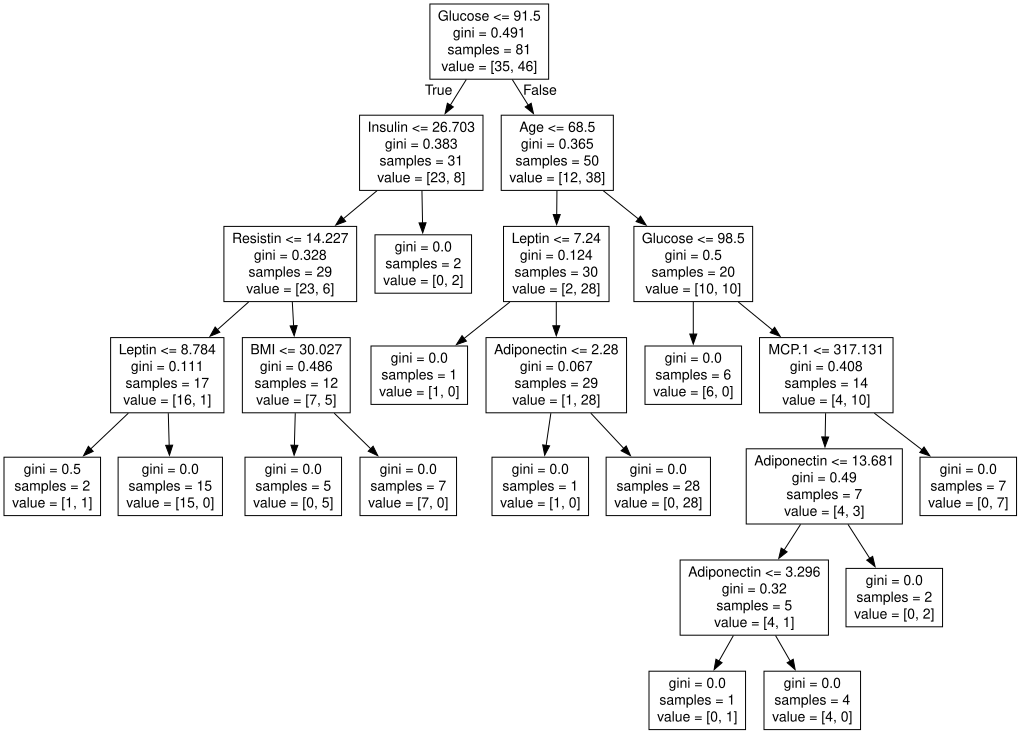

In [31]:
from graphviz import Source
dot_data = tree.export_graphviz(DT, out_file = None, feature_names = X_train.columns)

Source(dot_data)

# Building a Neural Network Model

In [32]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [33]:
# this will allow us to see the first 3 rows of the training set
X_train_scaled[:3] 

array([[0.78461538, 0.24707334, 0.09923664, 0.04497751, 0.01837585,
        0.14907699, 0.2727291 , 0.04919888, 0.16486718],
       [0.29230769, 0.85660133, 0.14503817, 0.37056472, 0.18491753,
        0.31292443, 0.18263354, 0.04436887, 0.55331276],
       [0.53846154, 0.23815519, 0.21374046, 0.07906761, 0.04471426,
        0.12321535, 0.07074776, 0.06331474, 0.18726102]])

In [34]:
# this will allow us to see the first 3 rows of the test set
X_test_scaled[:3]

array([[0.72307692, 0.3810268 , 0.32061069, 0.14212537, 0.09425257,
        0.17162349, 0.10526831, 0.50113703, 0.45628487],
       [0.95384615, 0.14627548, 0.16793893, 0.01993646, 0.00986285,
        0.02778211, 0.08693991, 0.09337495, 0.44056536],
       [0.78461538, 0.4765367 , 0.11450382, 0.04935032, 0.02147136,
        0.07071154, 0.20186865, 0.05535176, 0.17520908]])

## Model Gereration

In [35]:
from sklearn.neural_network import MLPClassifier

NN = MLPClassifier(solver = 'lbfgs', alpha= 1e-5, hidden_layer_sizes= (10,4), random_state = 1)

NN.fit(X_train_scaled, y_train)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(10, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'lbfgs'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",1e-05
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",200
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",1


In [36]:
NN_pred = NN.predict(X_test_scaled)

round((metrics.accuracy_score(NN_pred, y_test) * 100),2)

74.29

## Creating a function for the Neural Network Model using Train and Test sets
- Displaying confusion maxtrices, accuracy scores, and correct predictions

In [37]:
def evaluate_neural_network(NN, X_train_scaled, X_test_scaled, y_train, y_test):
    
    # Make predictions
    NN_train_pred = NN.predict(X_train_scaled)
    NN_test_pred = NN.predict(X_test_scaled)
    
    # Accuracy scores
    NN_train_accuracy = round(metrics.accuracy_score(y_train, NN_train_pred) * 100, 2)
    NN_test_accuracy = round(metrics.accuracy_score(y_test, NN_test_pred) * 100, 2)
    
    print(f"Accuracy score for train set: {NN_train_accuracy}%")
    print(f"Accuracy score for test set: {NN_test_accuracy}%")
    
    # Classification report
    print("\nClassification Report:")
    print(metrics.classification_report(y_test, NN_test_pred))
    
    # Confusion matrices
    NN_train_cm = metrics.confusion_matrix(y_train, NN_train_pred)
    NN_test_cm = metrics.confusion_matrix(y_test, NN_test_pred)
    
    print("\nTraining Confusion Matrix:")
    print(NN_train_cm)
    
    print("\nTesting Confusion Matrix:")
    print(NN_test_cm)
    
    # Pull correct predictions from diagonal
    NN_train_healthy = NN_train_cm.diagonal()[0]
    NN_train_patients = NN_train_cm.diagonal()[1]
    NN_train_total_correct = NN_train_cm.diagonal().sum()
    
    NN_test_healthy = NN_test_cm.diagonal()[0]
    NN_test_patients = NN_test_cm.diagonal()[1]
    NN_test_total_correct = NN_test_cm.diagonal().sum()
    
    # Show training results
    print("\nTraining Data Results:")
    print(f"Correct amount of predictions for class 1 Healthy Controls: {NN_train_healthy}")
    print(f"Correct amount of predictions for class 2 Patients: {NN_train_patients}")
    print(f"Correct amount of predictions made for both classes using the training data: {NN_train_total_correct}")
    
    # Show testing results
    print("\nTesting Data Results:")
    print(f"Correct amount of predictions for class 1 Healthy Controls: {NN_test_healthy}")
    print(f"Correct amount of predictions for class 2 Patients: {NN_test_patients}")
    print(f"Correct amount of predictions made for both classes using the testing data: {NN_test_total_correct}")
    
    return NN_train_cm, NN_test_cm

NN_train_cm, NN_test_cm = evaluate_neural_network(NN, X_train_scaled, X_test_scaled, y_train, y_test)

Accuracy score for train set: 87.65%
Accuracy score for test set: 74.29%

Classification Report:
              precision    recall  f1-score   support

           1       0.72      0.76      0.74        17
           2       0.76      0.72      0.74        18

    accuracy                           0.74        35
   macro avg       0.74      0.74      0.74        35
weighted avg       0.74      0.74      0.74        35


Training Confusion Matrix:
[[30  5]
 [ 5 41]]

Testing Confusion Matrix:
[[13  4]
 [ 5 13]]

Training Data Results:
Correct amount of predictions for class 1 Healthy Controls: 30
Correct amount of predictions for class 2 Patients: 41
Correct amount of predictions made for both classes using the training data: 71

Testing Data Results:
Correct amount of predictions for class 1 Healthy Controls: 13
Correct amount of predictions for class 2 Patients: 13
Correct amount of predictions made for both classes using the testing data: 26


## Neural Network Analysis

The Neural Network model had a training accuracy of 87.65 % and a test accuracy of 74.29 %. In the training confusion matrix, the model correctly predicted 30 healthy controls and 41 patients. In the test confusion matrix, the model correctly predicted 13 healthy controls and 13 patients. It incorrectly predicted 4 healthy controls as patients and 5 patients as healthy controls. With a total of 71 (training) and 26 (testing) correct predictions using the training and test sets.

NameError: name 'train_total_correct' is not defined